In [1]:
import pandas as pd
import missingno as msno
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier



In [2]:
df=pd.read_csv(r'Admission_Predict.csv')
df

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65
...,...,...,...,...,...,...,...,...,...
395,396,324,110,3,3.5,3.5,9.04,1,0.82
396,397,325,107,3,3.0,3.5,9.11,1,0.84
397,398,330,116,4,5.0,4.5,9.45,1,0.91
398,399,312,103,3,3.5,4.0,8.78,0,0.67


<Axes: >

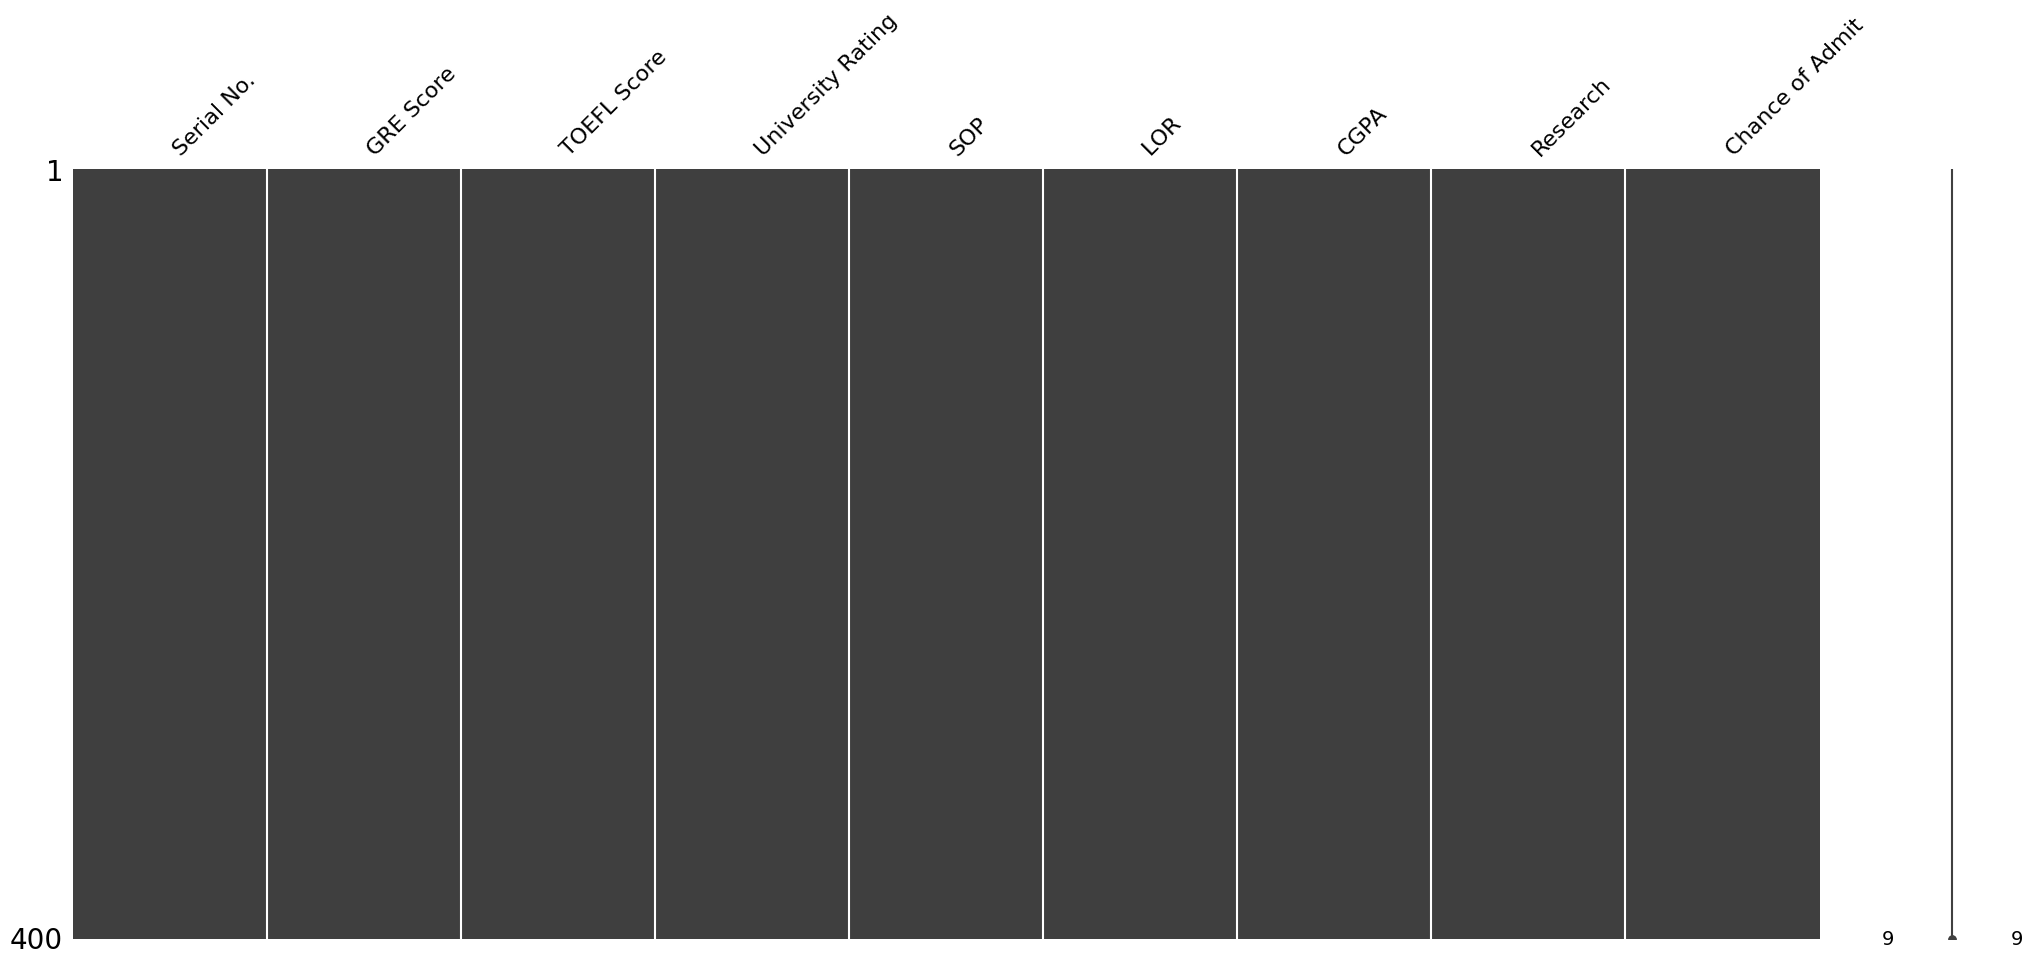

In [3]:
msno.matrix(df)

In [4]:
df[df.duplicated()].sum()

Serial No.           0.0
GRE Score            0.0
TOEFL Score          0.0
University Rating    0.0
SOP                  0.0
LOR                  0.0
CGPA                 0.0
Research             0.0
Chance of Admit      0.0
dtype: float64

In [5]:
df.columns=df.columns.str.strip()


### Seperate Dependent and Independent Variable

In [6]:
df['Admit'] = (df['Chance of Admit'] >= 0.75).astype(int)

x = df.drop(['Chance of Admit','Admit'], axis=1)
y = df['Admit']

### Split the train and test data

In [7]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

### Define Pipelining

In [28]:
pipeline=Pipeline([
    ('classifier',LogisticRegression())
])
Search_space=[
    {
        'classifier':[LogisticRegression(max_iter=500)],
        'classifier__C':[0.1,1,10],
        'classifier__solver':['liblinear','lbfgs']
    },
    {
        'classifier':[SVC()],
        'classifier__C':[0.1,1,10],
        'classifier__kernel':['linear','rbf']
    },
    {
        'classifier': [DecisionTreeClassifier()],
        'classifier__max_depth': [3, 5, None],
        'classifier__criterion': ['gini', 'entropy']
    },
    {
        'classifier': [RandomForestClassifier()],
        'classifier__n_estimators': [50, 100, 200],
        'classifier__max_depth': [3, 5, None]
    }
]

In [29]:
grid=GridSearchCV(pipeline,Search_space,cv=5,scoring='accuracy')

In [30]:
print ("Mode and Parameter Selection")
grid.fit(x_train,y_train)

Mode and Parameter Selection


C:\Users\arbag\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\arbag\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/st

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('classifier', LogisticRegression())]),
             param_grid=[{'classifier': [LogisticRegression(max_iter=500)],
                          'classifier__C': [0.1, 1, 10],
                          'classifier__solver': ['liblinear', 'lbfgs']},
                         {'classifier': [SVC()], 'classifier__C': [0.1, 1, 10],
                          'classifier__kernel': ['linear', 'rbf']},
                         {'classifier': [DecisionTreeClassifier()],
                          'classifier__criterion': ['gini', 'entropy'],
                          'classifier__max_depth': [3, 5, None]},
                         {'classifier': [RandomForestClassifier()],
                          'classifier__max_depth': [3, 5, None],
                          'classifier__n_estimators': [50, 100, 200]}],
             scoring='accuracy')

In [31]:
print(f"Best Algo:{grid.best_params_['classifier']}")
print(f"Best Parameter:{grid.best_params_}")
print(f"Best Accuracy:{grid.best_score_:.4f}")

Best Algo:LogisticRegression(max_iter=500)
Best Parameter:{'classifier': LogisticRegression(max_iter=500), 'classifier__C': 1, 'classifier__solver': 'lbfgs'}
Best Accuracy:0.8531


In [32]:
from sklearn.metrics import accuracy_score,classification_report

In [33]:
y_pred=grid.predict(x_test)
final_acc=accuracy_score(y_test,y_pred)

In [34]:
print(f"Test Accuracy: {final_acc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Rejected","Admitted"]))

Test Accuracy: 0.9250

Classification Report:
              precision    recall  f1-score   support

    Rejected       0.98      0.89      0.93        47
    Admitted       0.86      0.97      0.91        33

    accuracy                           0.93        80
   macro avg       0.92      0.93      0.92        80
weighted avg       0.93      0.93      0.93        80



In [35]:
import pickle

# Save the model
with open('admission_model.pkl', 'wb') as f:
    pickle.dump(grid.best_estimator_, f)

print("Model saved successfully!")

Model saved successfully!
